In [ ]:
# =============================================================================
# SETUP (if code up to token counting has not been run yet)
# =============================================================================

# Uncomment if needed
# %pip install -U openai pandas tqdm

import json
import time
import pandas as pd
from tqdm.auto import tqdm
from openai import OpenAI

# =============================================================================
# CONFIGURATION
# =============================================================================

from dotenv import load_dotenv
import os

load_dotenv()

client = OpenAI(
    api_key=os.environ["OPENAI_API_KEY"]
)

MODEL = "gpt-4o"
# MODEL = "gpt-4.1-mini"   # cheaper alternative

INPUT_CSV = "data/solar_articles.csv"

OUTPUT_JSON = "graph/solar_graphs.json"
OUTPUT_NODES = "graph/nodes.csv"
OUTPUT_EDGES = "graph/edges.csv"

SAVE_CHECKPOINT_EVERY = 25

# =============================================================================
# LOAD DATA
# =============================================================================

df = pd.read_csv(INPUT_CSV)

print(f"Loaded {len(df)} articles")

# Optional:
# df = df.head(100)

Loaded 5374 articles


In [2]:
# =============================================================================
# COUNT TOKENS IN ARTICLES
# =============================================================================

# Install if needed:
# %pip install tiktoken

import tiktoken
import pandas as pd

# Use the tokenizer closest to your model
encoding = tiktoken.encoding_for_model(MODEL)


def count_tokens(text):
    """
    Count tokens in a string using the model tokenizer.
    """
    if pd.isna(text):
        return 0
    
    return len(
        encoding.encode(str(text))
    )


# Count tokens in article text
df["token_count"] = df["text"].apply(count_tokens)


print(df[[
    "title",
    "token_count"
]].head())


print("\nToken statistics:")
print(df["token_count"].describe())


                                               title  token_count
0       UPDATE: You asked, the White House responds!          382
1  'Starry Night' bike path illuminates the groun...          210
2         Assessing the Value of Small Wind Turbines           32
3  How 24 Sussex Drive can become the greenest of...         1444
4  What Electric Grid Operators Want: Good Wind E...          732

Token statistics:
count     5374.000000
mean      1241.775214
std       1545.379231
min         18.000000
25%        583.000000
50%        941.500000
75%       1344.500000
max      42954.000000
Name: token_count, dtype: float64


In [3]:
import uuid

# Create stable article IDs
df["article_id"] = [
    f"article_{i:06d}"
    for i in range(len(df))
]

# Save updated CSV
df.to_csv(
    "solar_articles_with_tokens.csv",
    index=False
)

In [3]:
# =============================================================================
# SETUP (if above code has been run previously)
# =============================================================================

import json
import time
import pandas as pd
from tqdm.auto import tqdm
from openai import OpenAI
from dotenv import load_dotenv
import os
import tiktoken
import pandas as pd

load_dotenv()

client = OpenAI(
    api_key=os.environ["OPENAI_API_KEY"]
)

MODEL = "gpt-4o"
# MODEL = "gpt-4.1-mini"   # cheaper alternative

INPUT_CSV = "data/solar_articles_w_tokens.csv"

OUTPUT_JSON = "graph/solar_graphs.json"
OUTPUT_NODES = "graph/nodes.csv"
OUTPUT_EDGES = "graph/edges.csv"

SAVE_CHECKPOINT_EVERY = 25

df = pd.read_csv(INPUT_CSV)

print(f"Loaded {len(df)} articles")

# Use the tokenizer closest to your model
encoding = tiktoken.encoding_for_model(MODEL)

# Optional:
# df = df.head(100)

Loaded 5374 articles


In [4]:
from pathlib import Path

SYSTEM_PROMPT = Path("prompts/system_prompt.txt").read_text()

USER_PROMPT = Path("prompts/user_prompt.txt").read_text()

with open("prompts/solar_graph_schema.json") as f:
    SOLAR_GRAPH_SCHEMA = json.load(f)

In [ ]:
system_prompt_tokens = len(encoding.encode(SYSTEM_PROMPT))
print(system_prompt_tokens, "tokens in system prompt")

1773 tokens in system prompt


In [8]:
total_tokens = df["token_count"].sum()
print(f"Total tokens: {total_tokens}")

Total tokens: 6673300


In [12]:
total_input_tokens = (system_prompt_tokens * len(df)) + total_tokens
print("Total input tokens: ", total_input_tokens)

MODEL_COST = 2.5

total_input_cost = total_input_tokens * MODEL_COST / 1000000

print("Total input cost: ", total_input_cost)

Total input tokens:  16201402
Total input cost:  40.503505


In [7]:
# =============================================================================
# EXTRACTION FUNCTION
# =============================================================================

def extract_article(row):

    prompt = USER_PROMPT.format(
        article_id=["article_id"],
        publication_date=row["date"],
        source=row["archive"],
        title=row["title"],
        summary=row.get("summary", ""),
        text=row["text"],
    )

    response = client.chat.completions.create(

        model=MODEL,

        temperature=0,

        messages=[
            {
                "role": "system",
                "content": SYSTEM_PROMPT
            },
            {
                "role": "user",
                "content": prompt
            }
        ],

        response_format={
            "type": "json_schema",
            "json_schema": SOLAR_GRAPH_SCHEMA
        }

    )

    return json.loads(response.choices[0].message.content)

In [8]:
# =============================================================================
# TEST EXTRACTION ON A SINGLE ARTICLE
# =============================================================================

# Change this index to test a different article
TEST_ARTICLE_IDX = 0

row = df.iloc[TEST_ARTICLE_IDX]

print(f"Testing article index {TEST_ARTICLE_IDX}")
print(f"Title: {row['title']}")
print(f"Article ID: {row.name}")

single_result = extract_article(row)

print("\nUnrelated:", single_result["unrelated"])
print("Nodes:", len(single_result["nodes"]))
print("Edges:", len(single_result["edges"]))

print("\nPreview of extracted JSON:")
print(json.dumps(single_result, indent=2))


Testing article index 0
Title: UPDATE: You asked, the White House responds!
Article ID: 0

Unrelated: True
Nodes: 0
Edges: 0

Preview of extracted JSON:
{
  "article_id": "article_id",
  "publication_date": "2011082419",
  "source": "https://web.archive.org/web/2011082419id_/http://ireport.cnn.com/blogs/ireport-blog/2011/08/22/update-you-asked-the-white-house-responds",
  "unrelated": true,
  "nodes": [],
  "edges": []
}


In [9]:
# =============================================================================
# TEST EXTRACTION ON A SINGLE ARTICLE
# =============================================================================

# Change this index to test a different article
TEST_ARTICLE_IDX = 5

row = df.iloc[TEST_ARTICLE_IDX]

print(f"Testing article index {TEST_ARTICLE_IDX}")
print(f"Title: {row['title']}")
print(f"Article ID: {row.name}")

single_result = extract_article(row)

print("\nUnrelated:", single_result["unrelated"])
print("Nodes:", len(single_result["nodes"]))
print("Edges:", len(single_result["edges"]))

print("\nPreview of extracted JSON:")
print(json.dumps(single_result, indent=2))


Testing article index 5
Title: Tesla Charges into Home Battery Market Despite Challenges
Article ID: 5

Unrelated: False
Nodes: 11
Edges: 6

Preview of extracted JSON:
{
  "article_id": "article_id",
  "publication_date": "2015050119",
  "source": "https://web.archive.org/web/2015050119id_/http://time.com/3842996/tesla-elon-musk-solar-panel-batteries/",
  "unrelated": false,
  "nodes": [
    {
      "id": "company:tesla",
      "type": "Company",
      "properties": {
        "name": "Tesla",
        "ticker": null,
        "headquarters": null,
        "country": null,
        "government_level": null,
        "organization_type": null,
        "policy_type": null,
        "jurisdiction": null,
        "enactment_year": null,
        "capacity": null,
        "location": null,
        "time_period": null,
        "location_type": null,
        "role_in_solar_energy_space": null
      },
      "mentions": [
        "Tesla",
        "Tesla Motors"
      ]
    },
    {
      "id": "perso

In [9]:
# =============================================================================
# TEST EXTRACTION ON 30 ARTICLES
# =============================================================================

TEST_ARTICLE_COUNT = 30
sample_df = df.iloc[:TEST_ARTICLE_COUNT].copy()

sample_results = []

for idx, row in tqdm(sample_df.iterrows(), total=len(sample_df)):

    try:
        result = extract_article(row)
        sample_results.append(result)

    except Exception as e:
        print(f"Article {idx} failed: {e}")

OUTPUT_TEST_JSON = "graph/solar_graphs_test30.json"

with open(OUTPUT_TEST_JSON, "w") as f:
    json.dump(sample_results, f, indent=2)

print(f"Saved {len(sample_results)} extracted graphs to {OUTPUT_TEST_JSON}")
print(f"Nodes collected: {sum(len(r['nodes']) for r in sample_results)}")
print(f"Edges collected: {sum(len(r['edges']) for r in sample_results)}")


  0%|          | 0/30 [00:00<?, ?it/s]

Saved 30 extracted graphs to graph/solar_graphs_test30.json
Nodes collected: 42
Edges collected: 24


In [ ]:
# =============================================================================
# RUN EXTRACTION
# =============================================================================

results = []

for idx, row in tqdm(df.iterrows(), total=len(df)):

    success = False

    for attempt in range(3):

        try:

            result = extract_article(row)

            results.append(result)

            success = True

            break

        except Exception as e:

            print(f"Row {idx} failed (attempt {attempt+1}): {e}")

            time.sleep(2)

    if not success:

        print(f"Skipping article {idx}")

    if len(results) % SAVE_CHECKPOINT_EVERY == 0:

        with open(OUTPUT_JSON, "w") as f:
            json.dump(results, f, indent=2)

In [ ]:
# =============================================================================
# SAVE FINAL JSON
# =============================================================================

with open(OUTPUT_JSON, "w") as f:
    json.dump(results, f, indent=2)

print(f"Saved {len(results)} extracted graphs.")

In [10]:
# =============================================================================
# FLATTEN NODES
# =============================================================================

nodes = []

for article in sample_results:

    for node in article["nodes"]:

        node_copy = node.copy()

        node_copy["article_id"] = article["article_id"]

        nodes.append(node_copy)

nodes_df = pd.DataFrame(nodes)

nodes_df.to_csv(OUTPUT_NODES, index=False)

print(f"Saved {len(nodes_df)} nodes.")

Saved 42 nodes.


In [11]:
# =============================================================================
# FLATTEN EDGES
# =============================================================================

edges = []

for article in sample_results:

    edges.extend(article["edges"])

edges_df = pd.DataFrame(edges)

edges_df.to_csv(OUTPUT_EDGES, index=False)

print(f"Saved {len(edges_df)} edges.")

Saved 24 edges.


In [12]:
# =============================================================================
# OPTIONAL ANALYSIS
# =============================================================================

print(nodes_df.head())

print(edges_df.head())

print(edges_df["relationship"].value_counts())

print(nodes_df["type"].value_counts())

# Example:
#
# company_nodes = nodes_df[nodes_df["type"] == "Company"]
#
# predictions = edges_df[
#     edges_df["relationship"] == "PREDICTS"
# ]
#
# partnerships = edges_df[
#     edges_df["relationship"] == "PARTNERS_WITH"
# ]
#
# unrelated_articles = [
#     r for r in results if r["unrelated"]
# ]
#
# print(len(unrelated_articles))


                     id        type  \
0         company:tesla     Company   
1      person:elon_musk      Person   
2  technology:powerwall  Technology   
3     company:solarcity     Company   
4   location:california    Location   

                                          properties  \
0  {'name': 'Tesla', 'ticker': None, 'headquarter...   
1  {'name': 'Elon Musk', 'ticker': None, 'headqua...   
2  {'name': 'Powerwall', 'ticker': None, 'headqua...   
3  {'name': 'SolarCity', 'ticker': None, 'headqua...   
4  {'name': 'California', 'ticker': None, 'headqu...   

                   mentions  article_id  
0     [Tesla, Tesla Motors]  article_id  
1         [Elon Musk, Musk]  article_id  
2  [Powerwall, the battery]  article_id  
3               [SolarCity]  article_id  
4              [California]  article_id  
              source                     target   relationship  article_id  \
0      company:tesla       technology:powerwall   MANUFACTURES  article_id   
1      company:tesla

In [16]:
%pip install networkx
%pip install matplotlib

Note: you may need to restart the kernel to use updated packages.
  Using cached contourpy-1.3.3-cp312-cp312-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached pyparsing-3.3.2-py3-none-any.whl.metadata (5.8 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.0/10.0 MB 2.9 MB/s  0:00:03m0:00:010:01
Using cached contourpy-1.3.3-cp312-cp312-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl (362 kB)
Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.0/5.0 MB 3.7 MB/s  0:00:01m0:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 3.6 MB/s  0:00:00 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 3.1 MB/s  0:00:02m0:00:0100:01
Using cached pyparsing-3.3.2-py3-none-any.whl (122 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7/7 [matplotlib]7 [matplotlib]
Note: you may need to restart the kernel to use updated packages.


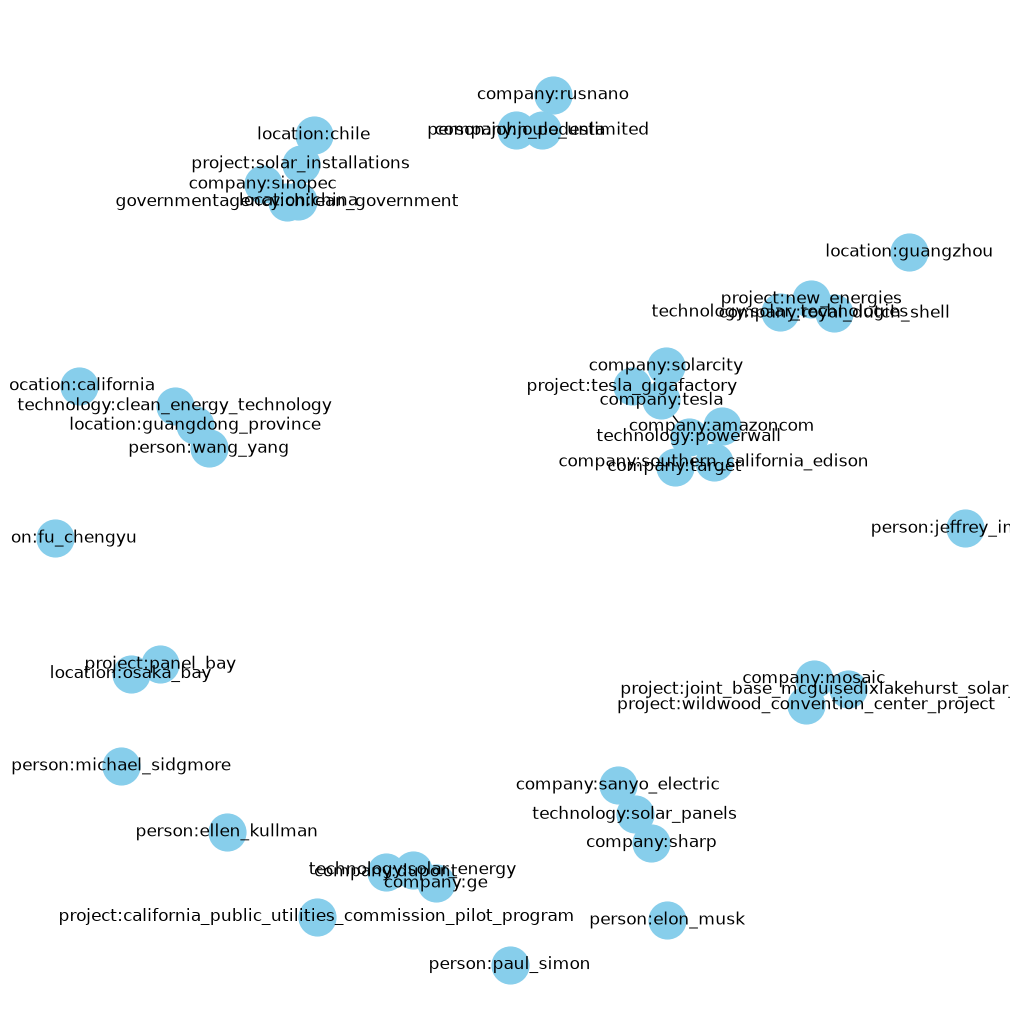

In [17]:
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt

# 1. Load your CSV files
nodes_df = pd.read_csv('graph/nodes.csv')
edges_df = pd.read_csv('graph/edges.csv')

# 2. Initialize the graph (use nx.DiGraph() for directed networks)
G = nx.Graph()

# 3. Add nodes with attributes (assumes a column named 'id')
for index, row in nodes_df.iterrows():
    G.add_node(row['id'], **row.drop('id').to_dict())

# 4. Add edges with attributes (assumes 'source' and 'target' columns)
for index, row in edges_df.iterrows():
    G.add_edge(row['source'], row['target'], **row.drop(['source', 'target']).to_dict())

# 5. Visualize the graph
plt.figure(figsize=(10, 10))
nx.draw(G, with_labels=True, node_color='skyblue', node_size=700, font_size=12)
plt.show()
